<a href="https://colab.research.google.com/github/sanme10/Urban_Heat_Island_Assessment_using_Remote_Sensing/blob/main/LST_Prediction_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import rasterio
import joblib  # For saving the model
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler

import rasterio
from rasterio.enums import Resampling

# Reference layer path
reference_layer = "D:/Final Year Project/Prediction dataset/ndvi2008.tif"

# All raster paths that need alignment
all_raster_paths = {
    'NDVI': [
        "D:/Final Year Project/Prediction dataset/ndvi2008.tif",
        "D:/Final Year Project/Prediction dataset/ndvi2013.tif",
        "D:/Final Year Project/Prediction dataset/ndvi2018.tif",
        "D:/Final Year Project/Prediction dataset/ndvi2023.tif"
    ],
    'NDBI': [
        "D:/Final Year Project/Prediction dataset/ndbi2008.tif",
        "D:/Final Year Project/Prediction dataset/ndbi2013.tif",
        "D:/Final Year Project/Prediction dataset/ndbi2018.tif",
        "D:/Final Year Project/Prediction dataset/ndbi2023.tif"
    ],
    'LST': [
        "D:/Final Year Project/Prediction dataset/lst2008.tif",
        "D:/Final Year Project/Prediction dataset/lst2013.tif",
        "D:/Final Year Project/Prediction dataset/lst2018.tif",
        "D:/Final Year Project/Prediction dataset/lst2023.tif"
    ],
    'LULC': [
        "D:/Final Year Project/Prediction dataset/lulc2008.tif",
        "D:/Final Year Project/Prediction dataset/lulc2013.tif",
        "D:/Final Year Project/Prediction dataset/lulc2018.tif",
        "D:/Final Year Project/Prediction dataset/lulc2023.tif"
    ],
    'Other': [
        "D:/Final Year Project/Prediction dataset/dem_final.tif",
        "D:/Final Year Project/Prediction dataset/slope_final.tif",
        "D:/Final Year Project/Prediction dataset/dist_road_final.tif",
        "D:/Final Year Project/Prediction dataset/aspect_final.tif"
    ]
}

def align_raster_to_reference(input_path, reference_path, output_path, is_categorical=False):
    """Align any raster to match the reference raster"""
    with rasterio.open(reference_path) as ref:
        ref_profile = ref.profile

    with rasterio.open(input_path) as src:
        # Choose appropriate resampling method
        resampling = Resampling.nearest if is_categorical else Resampling.bilinear

        # Read data with resampling
        data = src.read(
            out_shape=(ref_profile['height'], ref_profile['width']),
            resampling=resampling
        )

        # Update output profile
        ref_profile.update({
            'dtype': data.dtype,
            'nodata': src.nodata,
            'count': src.count
        })

        # Write output
        with rasterio.open(output_path, 'w', **ref_profile) as dst:
            dst.write(data)

# Process all rasters
for category, paths in all_raster_paths.items():
    print(f"\nProcessing {category} rasters...")
    for input_path in paths:
        output_path = input_path.replace('.tif', '_aligned.tif')
        print(f"Aligning {input_path} to reference...")

        # Use nearest neighbor for LULC (categorical), bilinear for others
        is_categorical = (category == 'LULC')
        align_raster_to_reference(
            input_path,
            reference_layer,
            output_path,
            is_categorical=is_categorical
        )
        print(f"Saved aligned version to {output_path}")

# Verification function
def verify_alignment(file_path, reference_path):
    with rasterio.open(reference_path) as ref:
        with rasterio.open(file_path) as test:
            checks = {
                'CRS': test.crs == ref.crs,
                'Dimensions': (test.width == ref.width) and (test.height == ref.height),
                'Transform': test.transform == ref.transform
            }
            return checks

# Verify all outputs
print("\nVerifying alignment...")
for category, paths in all_raster_paths.items():
    print(f"\nVerifying {category} rasters:")
    for input_path in paths:
        output_path = input_path.replace('.tif', '_aligned.tif')
        results = verify_alignment(output_path, reference_layer)
        print(f"{output_path}:")
        for check, passed in results.items():
            print(f"  {check}: {'PASS' if passed else 'FAIL'}")

print("\nAll rasters have been processed and verified!")


Processing NDVI rasters...
Aligning D:/Final Year Project/Prediction dataset/ndvi2008.tif to reference...
Saved aligned version to D:/Final Year Project/Prediction dataset/ndvi2008_aligned.tif
Aligning D:/Final Year Project/Prediction dataset/ndvi2013.tif to reference...
Saved aligned version to D:/Final Year Project/Prediction dataset/ndvi2013_aligned.tif
Aligning D:/Final Year Project/Prediction dataset/ndvi2018.tif to reference...
Saved aligned version to D:/Final Year Project/Prediction dataset/ndvi2018_aligned.tif
Aligning D:/Final Year Project/Prediction dataset/ndvi2023.tif to reference...
Saved aligned version to D:/Final Year Project/Prediction dataset/ndvi2023_aligned.tif

Processing NDBI rasters...
Aligning D:/Final Year Project/Prediction dataset/ndbi2008.tif to reference...
Saved aligned version to D:/Final Year Project/Prediction dataset/ndbi2008_aligned.tif
Aligning D:/Final Year Project/Prediction dataset/ndbi2013.tif to reference...
Saved aligned version to D:/Final Y

In [ ]:
# New LULC 2028 path
lulc_2028_path = "D:/Final Year Project/Prediction dataset/lulc2028.tif"
output_2028_path = "D:/Final Year Project/Prediction dataset/lulc2028_aligned.tif"

# Align LULC 2028 with reference
print(f"Aligning {lulc_2028_path} to reference...")
align_raster_to_reference(
    lulc_2028_path,
    reference_layer,  # Your existing reference (ndvi2008.tif)
    output_2028_path,
    is_categorical=True  # Using nearest neighbor for LULC
)

# Verify the alignment
print("\nVerification results:")
results = verify_alignment(output_2028_path, reference_layer)
for check, passed in results.items():
    print(f"{check}: {'✓' if passed else '✗'}")

print(f"\nAligned LULC 2028 saved to: {output_2028_path}")

Aligning D:/Final Year Project/Prediction dataset/lulc2028.tif to reference...

Verification results:
CRS: ✓
Dimensions: ✓
Transform: ✓

Aligned LULC 2028 saved to: D:/Final Year Project/Prediction dataset/lulc2028_aligned.tif


In [ ]:
import numpy as np
import pandas as pd
import rasterio
import joblib  # For saving the model
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler

# 1️⃣ File Paths for NDVI, NDBI, LST, and other layers
ndvi_paths = [
    "D:/Final Year Project/Prediction dataset/ndvi2008_aligned.tif",
    "D:/Final Year Project/Prediction dataset/ndvi2013_aligned.tif",
    "D:/Final Year Project/Prediction dataset/ndvi2018_aligned.tif",
    "D:/Final Year Project/Prediction dataset/ndvi2023_aligned.tif"

]

ndbi_paths = [
"D:/Final Year Project/Prediction dataset/ndbi2008_aligned.tif",
"D:/Final Year Project/Prediction dataset/ndbi2013_aligned.tif",
"D:/Final Year Project/Prediction dataset/ndbi2018_aligned.tif",
"D:/Final Year Project/Prediction dataset/ndbi2023_aligned.tif"

]

lst_paths = [
"D:/Final Year Project/Prediction dataset/lst2008_aligned.tif",
"D:/Final Year Project/Prediction dataset/lst2013_aligned.tif",
"D:/Final Year Project/Prediction dataset/lst2018_aligned.tif",
"D:/Final Year Project/Prediction dataset/lst2023_aligned.tif"

]
lulc_paths= [
"D:/Final Year Project/Prediction dataset/lulc2008_aligned.tif",
"D:/Final Year Project/Prediction dataset/lulc2013_aligned.tif",
"D:/Final Year Project/Prediction dataset/lulc2018_aligned.tif",
"D:/Final Year Project/Prediction dataset/lulc2023_aligned.tif"

]

# Paths for the resampled layers
elevation_path = "D:/Final Year Project/Prediction dataset/dem_final_aligned.tif"
slope_path = "D:/Final Year Project/Prediction dataset/slope_final_aligned.tif"
road_distance_path = "D:/Final Year Project/Prediction dataset/dist_road_final_aligned.tif"
aspect_path = "D:/Final Year Project/Prediction dataset/aspect_final_aligned.tif"

# 2️⃣ Create DataFrame
data = pd.DataFrame()

for i, year in enumerate([2008, 2013, 2018, 2023]):
    with rasterio.open(lulc_paths[i]) as lulc_src, \
         rasterio.open(lst_paths[i]) as lst_src, \
         rasterio.open(elevation_path) as elevation_src, \
         rasterio.open(slope_path) as slope_src, \
         rasterio.open(aspect_path) as aspect_src, \
         rasterio.open(road_distance_path) as road_distance_src:

        # Read and flatten the data
        lulc = lulc_src.read(1).flatten()
        lst = lst_src.read(1).flatten()
        elevation = elevation_src.read(1).flatten()
        slope = slope_src.read(1).flatten()
        road_distance = road_distance_src.read(1).flatten()
        aspect = aspect_src.read(1).flatten()

        # Read NoData values
        lulc_nodata = lulc_src.nodata
        lst_nodata = lst_src.nodata
        elev_nodata = elevation_src.nodata
        slope_nodata = slope_src.nodata
        road_nodata = road_distance_src.nodata
        aspect_nodata = aspect_src.nodata

        # Create a valid mask where all layers are not equal to their NoData value
        valid_mask = np.ones_like(lulc, dtype=bool)

        if lulc_nodata is not None:
            valid_mask &= lulc != lulc_nodata
        if lst_nodata is not None:
            valid_mask &= lst != lst_nodata
        if elev_nodata is not None:
            valid_mask &= elevation != elev_nodata
        if slope_nodata is not None:
            valid_mask &= slope != slope_nodata
        if road_nodata is not None:
            valid_mask &= road_distance != road_nodata
        if aspect_nodata is not None:
            valid_mask &= aspect != aspect_nodata

        # Apply the mask
        df = pd.DataFrame({
            "LULC": lulc[valid_mask],
            "LST": lst[valid_mask],
            "Year": year,
            "Elevation": elevation[valid_mask],
            "Slope": slope[valid_mask],
            "Road_Distance": road_distance[valid_mask],
            "Aspect": aspect[valid_mask]
        })

        data = pd.concat([data, df], ignore_index=True)

# Feature Engineering
data["Time"] = data["Year"].apply(lambda year: (year - 2008) / 20)

# Final cleanup
data = data.dropna()
print(data.tail())
# print("\nNaN count per column:\n", data.isna().sum())


         LULC        LST  Year  Elevation      Slope  Road_Distance  \
4531986   1.0  27.815521  2023        446  22.985601    3213.001953   
4531987   3.0  27.815521  2023        443  15.149271    3212.493652   
4531988   3.0  27.908529  2023        442  10.444669    3212.202881   
4531989   2.0  27.973588  2023        439   6.982069    3242.334229   
4531990   3.0  28.059834  2023        441   4.908344    3242.046143   

             Aspect  Time  
4531986  165.301819  0.75  
4531987  160.250381  0.75  
4531988  156.281738  0.75  
4531989  186.432907  0.75  
4531990  171.469238  0.75  


In [ ]:
# Assuming 'data' is your dataframe and 'LST' is the column containing LST values
lst_min = data['LST'].min()
lst_max = data['LST'].max()

print("Minimum LST:", lst_min)
print("Maximum LST:", lst_max)

Minimum LST: 9.994160123418965
Maximum LST: 42.865935658001604


In [ ]:
print(data.describe())



               LULC           LST          Year     Elevation         Slope  \
count  4.531991e+06  4.531991e+06  4.531991e+06  4.531991e+06  4.531991e+06   
mean   1.478343e+00  2.631407e+01  2.015500e+03  1.543423e+03  1.834915e+01   
std    1.442636e+00  4.374451e+00  5.590222e+00  3.224642e+02  1.294782e+01   
min    0.000000e+00  9.994160e+00  2.008000e+03  4.250000e+02  0.000000e+00   
25%    0.000000e+00  2.318478e+01  2.008000e+03  1.337000e+03  6.265447e+00   
50%    1.000000e+00  2.690032e+01  2.018000e+03  1.442000e+03  1.688717e+01   
75%    3.000000e+00  2.966563e+01  2.023000e+03  1.741000e+03  2.838057e+01   
max    4.000000e+00  4.286594e+01  2.023000e+03  2.821000e+03  6.920705e+01   

       Road_Distance        Aspect          Time  
count   4.531991e+06  4.531991e+06  4.531991e+06  
mean    8.555236e+02  1.801359e+02  3.750021e-01  
std     7.149404e+02  9.157386e+01  2.795111e-01  
min     0.000000e+00 -1.000000e+00  0.000000e+00  
25%     2.967267e+02  1.076260e+0

In [ ]:

# Display summary statistics of the normalized data
print(data.describe())

               LULC           LST          Year     Elevation         Slope  \
count  4.531991e+06  4.531991e+06  4.531991e+06  4.531991e+06  4.531991e+06   
mean   1.478343e+00  2.631407e+01  2.015500e+03  1.543423e+03  1.834915e+01   
std    1.442636e+00  4.374451e+00  5.590222e+00  3.224642e+02  1.294782e+01   
min    0.000000e+00  9.994160e+00  2.008000e+03  4.250000e+02  0.000000e+00   
25%    0.000000e+00  2.318478e+01  2.008000e+03  1.337000e+03  6.265447e+00   
50%    1.000000e+00  2.690032e+01  2.018000e+03  1.442000e+03  1.688717e+01   
75%    3.000000e+00  2.966563e+01  2.023000e+03  1.741000e+03  2.838057e+01   
max    4.000000e+00  4.286594e+01  2.023000e+03  2.821000e+03  6.920705e+01   

       Road_Distance        Aspect          Time  
count   4.531991e+06  4.531991e+06  4.531991e+06  
mean    8.555236e+02  1.801359e+02  3.750021e-01  
std     7.149404e+02  9.157386e+01  2.795111e-01  
min     0.000000e+00 -1.000000e+00  0.000000e+00  
25%     2.967267e+02  1.076260e+0

In [ ]:

# 5️⃣ Split Data into Features (X) and Target (y)
X = data[["LULC", "Time", "Elevation", "Slope", "Road_Distance","Aspect"]]
y = data["LST"]


In [ ]:

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import joblib

# 7️⃣ Train-Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 8️⃣ Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 9️⃣ Optimized Random Forest Model
model = RandomForestRegressor(
    n_estimators=200,         # Reduced trees to speed up
    max_depth=20,             # Slightly shallower trees
    min_samples_split=5,     # Helps reduce overfitting + faster
    min_samples_leaf=2,       # Fewer leaves
    n_jobs=-1,                # 💥 USE ALL CPU CORES
    random_state=42
)

model.fit(X_train_scaled, y_train)

# 🔟 Model Evaluation
y_pred = model.predict(X_test_scaled)

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mse)
print(f"✅ Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"✅ Mean Squared Error: {mse:.4f}")
print(f"✅ Mean Absolute Error: {mae:.4f}")
print(f"✅ R-squared Score: {r2:.4f}")

#  Save Model & Scaler
joblib.dump(model, "D:/Final Year Project/LST_prediction_model_lulc.pkl")
joblib.dump(scaler, "D:/Final Year Project/scaler1_lulc.pkl")

print("✅ Model and scaler saved successfully!")


✅ Root Mean Squared Error (RMSE): 1.8739
✅ Mean Squared Error: 3.5117
✅ Mean Absolute Error: 1.4033
✅ R-squared Score: 0.8167
✅ Model and scaler saved successfully!


In [ ]:
import matplotlib.pyplot as plt

# Calculate residuals
residuals = y_test - y_pred

# Plot residuals
plt.figure(figsize=(8, 6))
plt.scatter(y_pred, residuals, alpha=0.5)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.show()

NameError: name 'y_test' is not defined

In [ ]:
import matplotlib.pyplot as plt

# Get feature importances
importances = model.feature_importances_
feature_names = X_train.columns  # Replace with your feature names

# Plot feature importances
plt.figure(figsize=(10, 6))
plt.barh(feature_names, importances)
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Random Forest Feature Importance')
plt.show()

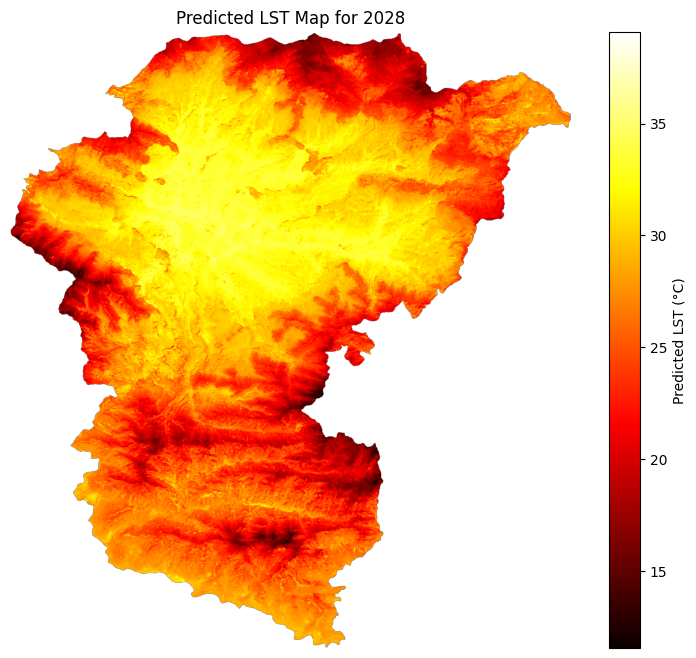

In [ ]:
import numpy as np
import pandas as pd
import rasterio
import joblib
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# File paths for input raster datasets
lulc_2028_path = "D:/Final Year Project/Prediction dataset/lulc2028_aligned.tif"
elevation_path = "D:/Final Year Project/Prediction dataset/dem_final_aligned.tif"
slope_path = "D:/Final Year Project/Prediction dataset/slope_final_aligned.tif"
road_distance_path = "D:/Final Year Project/Prediction dataset/dist_road_final_aligned.tif"
aspect_path = "D:/Final Year Project/Prediction dataset/aspect_final_aligned.tif"

# Open raster files and read the data
with rasterio.open(lulc_2028_path) as lulc_src, \
     rasterio.open(elevation_path) as elevation_src, \
     rasterio.open(slope_path) as slope_src, \
     rasterio.open(road_distance_path) as road_distance_src, \
     rasterio.open(aspect_path) as aspect_src:

    # Read and flatten the data
    lulc = lulc_src.read(1)
    elevation = elevation_src.read(1)
    slope = slope_src.read(1)
    road_distance = road_distance_src.read(1)
    aspect = aspect_src.read(1)

    # Save the 2D shape of the raster
    raster_shape = lulc.shape  # e.g., (rows, cols)

    # Flatten the arrays for processing
    lulc = lulc.flatten()
    elevation = elevation.flatten()
    slope = slope.flatten()
    road_distance = road_distance.flatten()
    aspect = aspect.flatten()

    # Read NoData values
    lulc_nodata = lulc_src.nodata
    elev_nodata = elevation_src.nodata
    slope_nodata = slope_src.nodata
    road_nodata = road_distance_src.nodata
    aspect_nodata = aspect_src.nodata

    # Create a valid mask where all layers are not equal to their NoData value
    valid_mask = np.ones_like(lulc, dtype=bool)

    if lulc_nodata is not None:
        valid_mask &= lulc != lulc_nodata
    if elev_nodata is not None:
        valid_mask &= elevation != elev_nodata
    if slope_nodata is not None:
        valid_mask &= slope != slope_nodata
    if road_nodata is not None:
        valid_mask &= road_distance != road_nodata
    if aspect_nodata is not None:
        valid_mask &= aspect != aspect_nodata

    # Prepare input DataFrame for prediction
    future_data = pd.DataFrame({
        "LULC": lulc[valid_mask],
        "Elevation": elevation[valid_mask],
        "Slope": slope[valid_mask],
        "Road_Distance": road_distance[valid_mask],
        "Aspect": aspect[valid_mask],
        "Time": [1] * np.sum(valid_mask)  # Set Time = 1 for 2028
    })

# Drop rows with NaN values
future_data = future_data.dropna()

# Load the trained model and scaler
model = joblib.load("D:/Final Year Project/LST_prediction_model_lulc.pkl")
scaler = joblib.load("D:/Final Year Project/scaler1_lulc.pkl")

# Select and scale features
X_2028 = future_data[["LULC", "Time", "Elevation", "Slope", "Road_Distance", "Aspect"]]
X_2028_scaled = scaler.transform(X_2028)

# Predict LST for 2028
predicted_lst_2028 = model.predict(X_2028_scaled)

# Reshape predictions to match raster
predicted_lst_2028_reshaped = np.full(raster_shape, np.nan)
predicted_lst_2028_reshaped.flat[valid_mask] = predicted_lst_2028  # Use original valid_mask

# Get metadata from elevation raster to retain georeferencing
with rasterio.open(elevation_path) as src:
    profile = src.profile

# Update profile for output
profile.update({
    "dtype": rasterio.float32,
    "count": 1
})

# Save predicted LST as GeoTIFF
output_path = "D:/Final Year Project/Prediction dataset/predicted_lst_2028.tif"
with rasterio.open(output_path, "w", **profile) as dst:
    dst.write(predicted_lst_2028_reshaped.astype(rasterio.float32), 1)

# Visualize predicted LST
plt.figure(figsize=(10, 8))
plt.imshow(predicted_lst_2028_reshaped, cmap='hot')
plt.colorbar(label='Predicted LST (°C)')
plt.title('Predicted LST Map for 2028')
plt.axis('off')
plt.show()


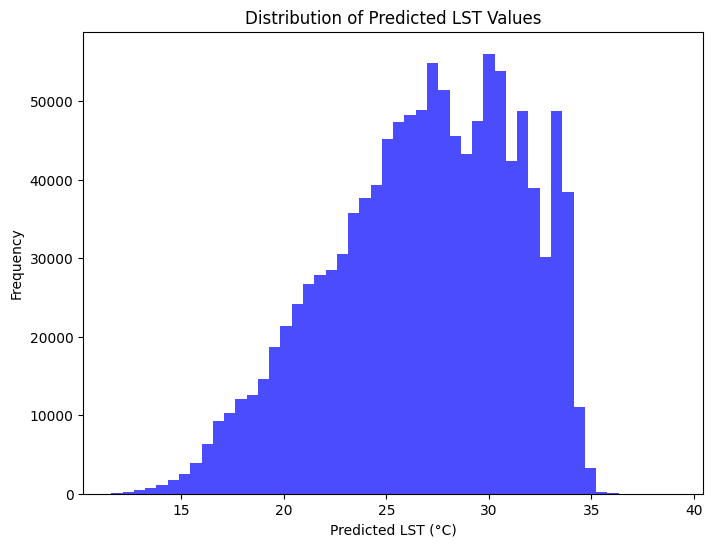

In [ ]:
# Plot histogram of predicted LST values
plt.figure(figsize=(8, 6))
plt.hist(predicted_lst_2028, bins=50, color='blue', alpha=0.7)
plt.title('Distribution of Predicted LST Values')
plt.xlabel('Predicted LST (°C)')
plt.ylabel('Frequency')
plt.show()


In [ ]:
# Calculate statistics for the denormalized LST values
lst_min_value = np.nanmin(predicted_lst_2028_reshaped)  # Minimum value (ignoring NaN)
lst_max_value = np.nanmax(predicted_lst_2028_reshaped)  # Maximum value (ignoring NaN)
lst_mean_value = np.nanmean(predicted_lst_2028_reshaped)  # Mean value (ignoring NaN)

# Print statistics
print(f"Minimum Predicted LST: {lst_min_value:.2f} °C")
print(f"Maximum Predicted LST: {lst_max_value:.2f} °C")
print(f"Mean Predicted LST: {lst_mean_value:.2f} °C")

Minimum Predicted LST: 11.58 °C
Maximum Predicted LST: 39.09 °C
Mean Predicted LST: 26.88 °C
